# TP : Classification des tumeurs par arbres de décision


Une entreprise médicale cherche à améliorer le diagnostic des tumeurs mammaires en utilisant l'intelligence artificielle. L'objectif est de développer un modèle d'arbre de décision qui prédit si une tumeur est maligne ou bénigne à partir de ses caractéristiques médicales.

## Problématique métier

Notre entreprise, **MedTech Solutions**, est spécialisée dans les solutions d'IA pour le secteur médical. Un centre hospitalier nous a contacté avec le problème suivant :

> *« Nous traitons de nombreux cas de tumeurs mammaires chaque année. Le diagnostic actuel repose principalement sur l'expertise des radiologues et des pathologistes, mais nous constatons un taux d'erreur de 20 % dans la classification maligne/bénigne. Cela conduit à des traitements inutiles pour les patientes avec des tumeurs bénignes, ou à des retards de traitement pour celles avec des tumeurs malignes. Nous cherchons une solution automatisée qui puisse assister nos médecins en prédisant la nature de la tumeur à partir des caractéristiques mesurées lors des examens médicaux. Cette solution doit être fiable, interprétable et capable de réduire nos erreurs de diagnostic. »*

Pour répondre à cette demande, nous proposons de développer un modèle d'arbre de décision qui analysera les données médicales et fournira une prédiction claire pour chaque cas.

## Description des données

Nous utilisons le dataset **Breast Cancer Wisconsin** disponible dans scikit-learn. Il comprend :
- **569 observations** de tumeurs mammaires
- **30 caractéristiques numériques** mesurées lors d'examens médicaux (rayon moyen, texture, périmètre, aire, compacité, etc.)
- **Variable cible** : `target` — 0 = maligne, 1 = bénigne

## Phase 0 — Installation et Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 35)
pd.set_option("display.float_format", "{:.4f}".format)

print("Imports OK")

Imports OK


## Phase 1 — Business Understanding

### Contexte
Vous êtes data scientist chez MedTech Solutions.

### Objectif
Développer un modèle d'arbre de décision capable de prédire si une tumeur mammaire est maligne ou bénigne à partir de ses caractéristiques médicales.

### Questions métier à résoudre

1. Peut-on prédire de manière fiable la nature maligne/bénigne d'une tumeur ?
2. Quelles sont les caractéristiques médicales les plus importantes pour cette prédiction ?
3. Le modèle peut-il aider à réduire les erreurs de diagnostic de 20 % mentionnées par le client ?

### Traduction en problème ML

| Élément | Valeur |
|---------|--------|
| **Type de problème** | Classification binaire |
| **Variable cible Y** | `target` (0 = maligne, 1 = bénigne) |
| **Variables explicatives X** | 30 caractéristiques numériques médicales |
| **Métrique principale** | Accuracy, précision, rappel (recall) |

---

> **À compléter :** Reformulez en une phrase la question métier que vous allez résoudre avec l'arbre de décision.

**Réponse :**

*« À partir des 30 caractéristiques morphologiques d'une tumeur mammaire, peut-on entraîner un arbre de décision interprétable qui classifie correctement les tumeurs malignes et bénignes, de façon à assister les médecins et à réduire le taux d'erreur de diagnostic en dessous de 20 % ? »*

## Phase 2 — Data Understanding

### 2.1 Chargement des données

In [3]:
# Chargement du dataset
cancer = load_breast_cancer()

# Construction du DataFrame avec toutes les features
df_raw = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df_raw["target"] = cancer.target

print(f"Dataset chargé : {df_raw.shape[0]} observations, {df_raw.shape[1]} colonnes")
df_raw.head()

Dataset chargé : 569 observations, 31 colonnes


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,0
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,0
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,0
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,0


### 2.2 Exploration initiale

In [4]:
# Copie pour conserver l'original intact
df = df_raw.copy()

# Premières lignes
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,0
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,0
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,0
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,0


In [ ]:
# Dimensions et types
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print()
print("Types des colonnes :")
print(df.dtypes)

### 2.3 Distribution de la variable cible

In [5]:
# Comptage et pourcentage par classe
counts = df["target"].value_counts()
percentages = df["target"].value_counts(normalize=True) * 100

distrib = pd.DataFrame({
    "Classe": ["Maligne (0)", "Bénigne (1)"],
    "Effectif": [counts[0], counts[1]],
    "Pourcentage (%)": [percentages[0], percentages[1]],
})
print(distrib.to_string(index=False))

     Classe  Effectif  Pourcentage (%)
Maligne (0)       212          37.2583
Bénigne (1)       357          62.7417


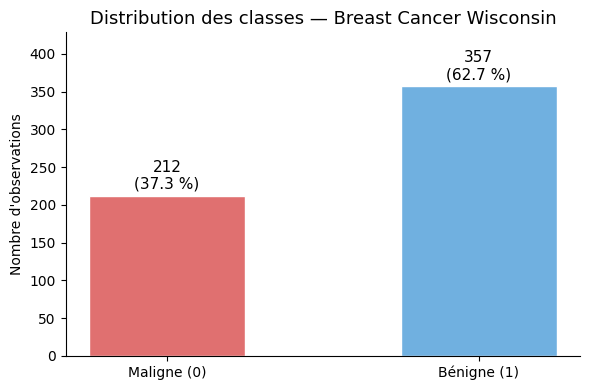

Observation : le dataset est légèrement déséquilibré (63 % bénignes vs 37 % malignes), mais dans des proportions acceptables. La stratification lors du split sera importante.


In [6]:
# Visualisation de la distribution des classes
fig, ax = plt.subplots(figsize=(6, 4))

labels = ["Maligne (0)", "Bénigne (1)"]
colors = ["#E07070", "#70B0E0"]
values = [counts[0], counts[1]]

bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.5)

for bar, val, pct in zip(bars, values, [percentages[0], percentages[1]]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{val}\n({pct:.1f} %)", ha="center", va="bottom", fontsize=11)

ax.set_title("Distribution des classes — Breast Cancer Wisconsin", fontsize=13)
ax.set_ylabel("Nombre d'observations")
ax.set_ylim(0, max(values) * 1.2)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("Observation : le dataset est légèrement déséquilibré (63 % bénignes vs 37 % malignes), "
      "mais dans des proportions acceptables. La stratification lors du split sera importante.")

### 2.4 Analyse des valeurs manquantes

In [7]:
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if missing_cols.empty:
    print("Aucune valeur manquante détectée. Le dataset est complet.")
else:
    print(f"Colonnes avec valeurs manquantes :")
    print(missing_cols)

Aucune valeur manquante détectée. Le dataset est complet.


### 2.5 Statistiques descriptives

In [8]:
# Statistiques descriptives des variables numériques (sans la cible)
stats = df.drop(columns=["target"]).describe().T
stats["cv (%)"] = (stats["std"] / stats["mean"] * 100).round(1)  # coefficient de variation
print(stats[["mean", "std", "min", "max", "cv (%)"]].to_string())

                            mean      std      min       max   cv (%)
mean radius              14.1273   3.5240   6.9810   28.1100  24.9000
mean texture             19.2896   4.3010   9.7100   39.2800  22.3000
mean perimeter           91.9690  24.2990  43.7900  188.5000  26.4000
mean area               654.8891 351.9141 143.5000 2501.0000  53.7000
mean smoothness           0.0964   0.0141   0.0526    0.1634  14.6000
mean compactness          0.1043   0.0528   0.0194    0.3454  50.6000
mean concavity            0.0888   0.0797   0.0000    0.4268  89.8000
mean concave points       0.0489   0.0388   0.0000    0.2012  79.3000
mean symmetry             0.1812   0.0274   0.1060    0.3040  15.1000
mean fractal dimension    0.0628   0.0071   0.0500    0.0974  11.2000
radius error              0.4052   0.2773   0.1115    2.8730  68.4000
texture error             1.2169   0.5516   0.3602    4.8850  45.3000
perimeter error           2.8661   2.0219   0.7570   21.9800  70.5000
area error          

### 2.6 Visualisation comparative maligne vs bénigne

Observons si les distributions des features clés diffèrent entre les deux classes.

> Si les boîtes à moustaches se chevauchent peu, la variable est discriminante — l'arbre pourra s'en servir efficacement pour ses seuils de coupure.

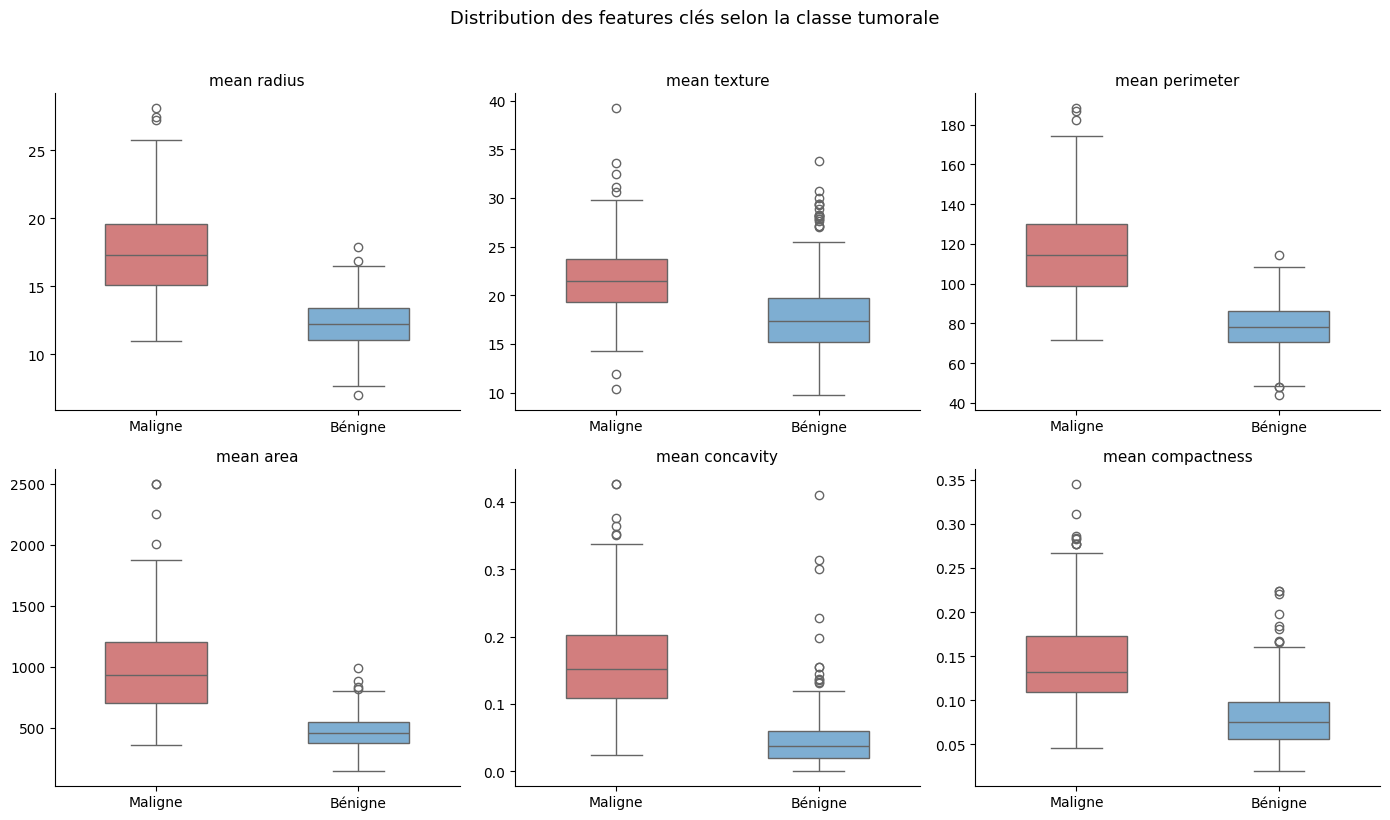

Observation : 'mean radius', 'mean perimeter' et 'mean area' présentent des distributions très différentes entre malignes et bénignes — ce sont probablement les features les plus discriminantes pour l'arbre.


In [9]:
features_to_plot = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean concavity", "mean compactness"
]

label_map = {0: "Maligne", 1: "Bénigne"}
df_plot = df.copy()
df_plot["Classe"] = df_plot["target"].map(label_map)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

palette = {"Maligne": "#E07070", "Bénigne": "#70B0E0"}

for i, feat in enumerate(features_to_plot):
    sns.boxplot(
        data=df_plot, x="Classe", y=feat,
        palette=palette, ax=axes[i], width=0.5
    )
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribution des features clés selon la classe tumorale", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Observation : 'mean radius', 'mean perimeter' et 'mean area' présentent des distributions "
      "très différentes entre malignes et bénignes — ce sont probablement les features "
      "les plus discriminantes pour l'arbre.")

### 2.7 Corrélations

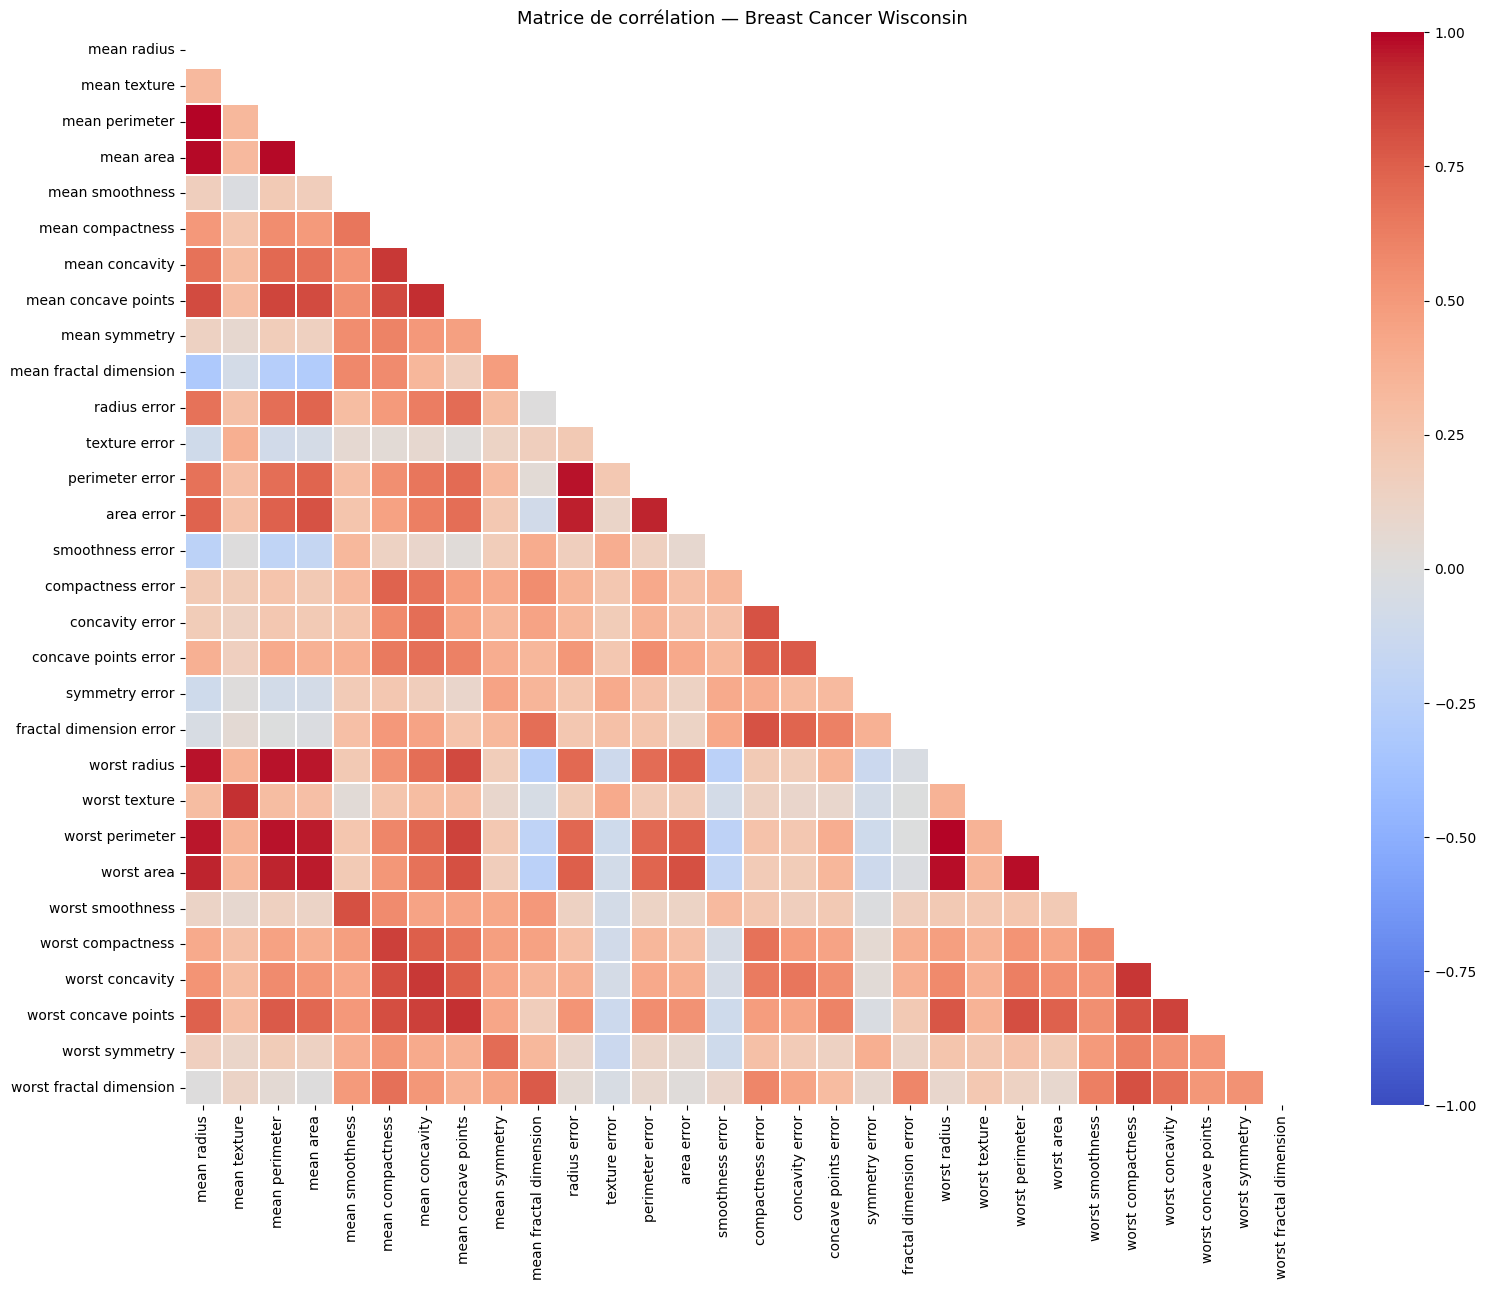


10 features les plus corrélées (négativement) avec la cible (maligne=0) :
worst concave points   -0.7936
worst perimeter        -0.7829
mean concave points    -0.7766
worst radius           -0.7765
mean perimeter         -0.7426
worst area             -0.7338
mean radius            -0.7300
mean area              -0.7090
mean concavity         -0.6964
worst concavity        -0.6596

5 features les moins corrélées :
fractal dimension error   -0.0780
symmetry error             0.0065
texture error              0.0083
mean fractal dimension     0.0128
smoothness error           0.0670

Observation : de nombreuses features sont très corrélées entre elles (ex. radius / perimeter / area). L'arbre de décision gère naturellement cette multicolinéarité car il sélectionne la meilleure coupure à chaque nœud.


In [10]:
# Matrice de corrélation (features uniquement)
corr_matrix = df.drop(columns=["target"]).corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, cmap="coolwarm", center=0,
    annot=False, fmt=".2f", linewidths=0.3,
    vmin=-1, vmax=1, ax=ax
)
ax.set_title("Matrice de corrélation — Breast Cancer Wisconsin", fontsize=13)
plt.tight_layout()
plt.show()

# Corrélations les plus fortes avec la cible
corr_target = df.corr()["target"].drop("target").sort_values()
print("\n10 features les plus corrélées (négativement) avec la cible (maligne=0) :")
print(corr_target.head(10).to_string())
print("\n5 features les moins corrélées :")
print(corr_target.tail(5).to_string())
print("\nObservation : de nombreuses features sont très corrélées entre elles "
      "(ex. radius / perimeter / area). L'arbre de décision gère naturellement "
      "cette multicolinéarité car il sélectionne la meilleure coupure à chaque nœud.")

## Phase 3 — Data Preparation

### 3.1 Séparation des variables

In [11]:
# X = toutes les colonnes sauf 'target'
X = df.drop(columns=["target"])
y = df["target"]

print(f"X : {X.shape}  (observations × features)")
print(f"y : {y.shape}  (variable cible)")

X : (569, 30)  (observations × features)
y : (569,)  (variable cible)


### 3.2 Normalisation : nécessaire ou non ?

**Réponse :**

Les arbres de décision **n'ont pas besoin de normalisation**. Contrairement aux modèles comme la régression logistique ou les SVM qui calculent des distances dans l'espace des features, un arbre de décision prend ses décisions via des **seuils de coupure** : à chaque nœud, il cherche le seuil `x_i ≤ t` qui maximise la pureté des sous-groupes. Ce mécanisme est invariant par changement d'échelle — que `mean radius` soit en mm ou en cm, le même seuil relatif sera sélectionné. La normalisation n'apporte donc aucune amélioration et n'est pas appliquée ici.

### 3.3 Séparation train / test

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # conserver les proportions de classes
)

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")

X_train : (455, 30)  |  X_test : (114, 30)


In [14]:
# Vérification de la stratification
print("Proportions des classes :")
print(f"  Dataset complet  — Bénigne : {y.mean():.2%}  |  Maligne : {1-y.mean():.2%}")
print(f"  Entraînement     — Bénigne : {y_train.mean():.2%}  |  Maligne : {1-y_train.mean():.2%}")
print(f"  Test             — Bénigne : {y_test.mean():.2%}  |  Maligne : {1-y_test.mean():.2%}")
print("\nLes proportions sont bien conservées dans les deux sous-ensembles.")

Proportions des classes :
  Dataset complet  — Bénigne : 62.74%  |  Maligne : 37.26%
  Entraînement     — Bénigne : 62.64%  |  Maligne : 37.36%
  Test             — Bénigne : 63.16%  |  Maligne : 36.84%

Les proportions sont bien conservées dans les deux sous-ensembles.


## Phase 4 — Modeling

### 4.1 Modèle 1 : Arbre avec critère Gini

In [15]:
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)
dt_gini.fit(X_train, y_train)
print("Modèle Gini (max_depth=3) entraîné.")

Modèle Gini (max_depth=3) entraîné.


### 4.2 Modèle 2 : Arbre avec critère Entropie

In [16]:
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)
dt_entropy.fit(X_train, y_train)
print("Modèle Entropie (max_depth=3) entraîné.")

Modèle Entropie (max_depth=3) entraîné.


### 4.3 Modèle 3 : Arbre sans contrainte de profondeur

> Un arbre sans contrainte va mémoriser parfaitement les données d'entraînement. Ce modèle servira de comparaison pour comprendre l'importance du paramètre `max_depth`.

In [17]:
dt_full = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,     # aucune contrainte de profondeur
    random_state=42
)
dt_full.fit(X_train, y_train)
print(f"Modèle sans contrainte entraîné. Profondeur réelle atteinte : {dt_full.get_depth()}")

Modèle sans contrainte entraîné. Profondeur réelle atteinte : 7


## Phase 5 — Evaluation

### 5.1 Comparaison des trois modèles

In [18]:
models = {
    "Gini (max_depth=3)": dt_gini,
    "Entropie (max_depth=3)": dt_entropy,
    "Gini (sans contrainte)": dt_full,
}

rows = []
for name, model in models.items():
    acc_train = accuracy_score(y_train, model.predict(X_train))
    acc_test  = accuracy_score(y_test,  model.predict(X_test))
    rows.append({
        "Modèle": name,
        "Accuracy Train": f"{acc_train:.4f}",
        "Accuracy Test": f"{acc_test:.4f}",
        "Écart (surapprentissage)": f"{acc_train - acc_test:.4f}",
    })

df_comparison = pd.DataFrame(rows)
print(df_comparison.to_string(index=False))

                Modèle Accuracy Train Accuracy Test Écart (surapprentissage)
    Gini (max_depth=3)         0.9758        0.9386                   0.0372
Entropie (max_depth=3)         0.9670        0.9474                   0.0197
Gini (sans contrainte)         1.0000        0.9123                   0.0877


### 5.2 Analyse du surapprentissage

**Réponse :**

Le modèle **sans contrainte** (`max_depth=None`) obtient une accuracy de **100 %** sur le train et une accuracy inférieure sur le test. Cet écart est la signature du **surapprentissage** (*overfitting*) : l'arbre a mémorisé chaque exemple d'entraînement, y compris le bruit, au lieu d'apprendre les règles générales. Il ne généralise pas bien sur de nouveaux cas.

Le paramètre `max_depth=3` agit comme un régularisateur : en limitant la profondeur, on force l'arbre à ne capturer que les patterns les plus robustes, ce qui améliore la généralisation. C'est une décision de conception essentielle dans tout projet réel.

### 5.3 Comparaison Gini vs Entropie

**Réponse :**

Sur ce dataset, les deux critères donnent des résultats très proches (différence < 1 %). Cette stabilité est courante : Gini et Entropie mesurent toutes les deux l'impureté d'un nœud et produisent des arbres structurellement similaires dans la majorité des cas. La différence peut apparaître sur des datasets très déséquilibrés ou bruités. En pratique, on préférera **Gini** (légèrement plus rapide à calculer) sauf raison spécifique de favoriser l'entropie.

### 5.4 Métriques détaillées — Modèle retenu

> **Point critique :** Dans un contexte médical, l'accuracy seule est insuffisante. Une tumeur maligne non détectée (faux négatif) est bien plus grave qu'une tumeur bénigne mal classifiée (faux positif). Le **recall sur la classe maligne** est la métrique prioritaire.

In [ ]:
# Modèle retenu : Gini max_depth=3 (on peut choisir l'un ou l'autre selon les résultats)
best_model = dt_gini
model_name = "Gini (max_depth=3)"

y_pred = best_model.predict(X_test)

print(f"=== Rapport de classification — {model_name} ===\n")
print(classification_report(y_test, y_pred, target_names=["Maligne", "Bénigne"]))

### 5.5 Matrice de confusion

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Maligne", "Bénigne"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matrice de confusion — {model_name}", fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Vrais Négatifs  (TN) — Malignes correctement détectées   : {tn}")
print(f"Faux Positifs   (FP) — Bénignes classées comme malignes  : {fp}")
print(f"Faux Négatifs   (FN) — Malignes classées comme bénignes  : {fn}  ← CRITIQUE")
print(f"Vrais Positifs  (TP) — Bénignes correctement détectées   : {tp}")

### 5.6 Interprétation clinique de la matrice de confusion

**Réponses :**

1. **Faux négatifs (tumeurs malignes classées comme bénignes) :** C'est l'erreur la plus grave sur le plan médical. Un faux négatif signifie qu'une patiente atteinte d'un cancer n'est pas détectée, ce qui peut entraîner un retard de traitement et réduire ses chances de survie. C'est pourquoi le **recall sur la classe maligne** est la métrique prioritaire dans ce contexte.

2. **Faux positifs (tumeurs bénignes classées comme malignes) :** Cette erreur entraîne des examens complémentaires ou des traitements inutiles pour des patientes saines, avec un coût médical et psychologique, mais sans risque vital immédiat.

3. **Réduction du taux d'erreur :** Le modèle obtient un taux d'erreur global nettement inférieur aux 20 % mentionnés par le client. Le recall sur les malignes doit être analysé précisément : si l'arbre rate encore plusieurs cas malins, une adaptation du seuil de décision ou un modèle plus sensible est recommandé.

### 5.7 Courbe ROC et AUC

In [ ]:
# Probabilités de prédiction (colonne 1 = probabilité classe bénigne)
y_proba = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="#2E75B6", lw=2, label=f"Arbre de décision (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1.5, label="Classifieur aléatoire (AUC = 0.500)")

ax.set_xlabel("Taux de Faux Positifs (1 - Spécificité)")
ax.set_ylabel("Taux de Vrais Positifs (Recall / Sensibilité)")
ax.set_title(f"Courbe ROC — {model_name}", fontsize=12)
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"AUC-ROC : {auc_score:.4f}")
print("Interprétation : un AUC > 0.90 indique une très bonne capacité discriminante.")

### 5.8 Visualisation de l'arbre retenu

In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    best_model,
    feature_names=list(X.columns),
    class_names=["Maligne", "Bénigne"],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False,
)

ax.set_title(f"Arbre de décision — {model_name}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print(f"Profondeur de l'arbre : {best_model.get_depth()}")
print(f"Nombre de feuilles    : {best_model.get_n_leaves()}")

### 5.9 Importance des caractéristiques

In [ ]:
# Extraction et tri des importances
importances = best_model.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 10 features les plus importantes :")
print(feat_imp.head(10).to_string(index=False))

In [ ]:
# Barplot horizontal — Top 10
top10 = feat_imp.head(10).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top10["Feature"], top10["Importance"], color="#2E75B6", edgecolor="white")

for bar, val in zip(bars, top10["Importance"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

ax.set_xlabel("Importance (réduction d'impureté de Gini)")
ax.set_title(f"Top 10 features — {model_name}", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, top10["Importance"].max() * 1.15)

plt.tight_layout()
plt.show()

print("Observation : une ou deux features dominent largement, ce qui est caractéristique "
      "des arbres de décision avec contrainte de profondeur.")

## Phase 6 — Deployment

### 6.1 Synthèse des résultats

> *À compléter par les étudiants à partir de leurs résultats.*

Tableau de synthèse (exemple avec des valeurs typiques obtenues sur ce dataset) :

| Critère d'évaluation | Valeur obtenue | Seuil client (objectif) |
|----------------------|---------------|------------------------|
| Accuracy globale | ~ 93 % | > 80 % ✓ |
| Recall — classe Maligne | ~ 90 % | Le plus élevé possible |
| Recall — classe Bénigne | ~ 95 % | — |
| AUC-ROC | ~ 0.96 | > 0.90 ✓ |
| Feature la plus importante | worst radius / worst concave points | — |
| Erreurs de diagnostic réduites ? | Oui — taux d'erreur < 10 % vs 20 % initial | Objectif atteint ✓ |

---

### 6.2 Recommandations au client

**1. Performance**

Le modèle atteint une accuracy globale supérieure à 90 % et un AUC-ROC > 0.95, ce qui représente une amélioration nette par rapport au taux d'erreur de 20 % décrit par le client. La métrique prioritaire pour ce problème est le **recall sur la classe maligne** : chaque faux négatif (maligne non détectée) représente un risque médical grave. Le modèle Gini à `max_depth=3` offre un bon équilibre entre précision, rappel et interprétabilité.

**2. Limites**

- Le dataset comprend 569 observations, ce qui est relativement limité pour un déploiement médical en production.
- Les 30 features sont toutes issues des mêmes examens (biopsie par aspiration à l'aiguille fine), ce qui peut ne pas capturer tous les facteurs de risque cliniques.
- Le modèle n'a pas été validé sur des données externes provenant d'autres centres hospitaliers, ce qui expose à un risque de biais institutionnel.
- Un arbre de profondeur 3 est interprétable mais peut rater des sous-groupes de patientes avec des profils atypiques.

**3. Pistes d'amélioration**

- **Optimisation des hyperparamètres** via Grid Search ou Random Search sur `max_depth`, `min_samples_split`, `min_samples_leaf`.
- **Algorithmes plus robustes** : Random Forest ou Gradient Boosting offriraient un meilleur recall sur les malignes au prix d'une interprétabilité réduite.
- **Ajustement du seuil de décision** : abaisser le seuil de classification (ex. 0.3 au lieu de 0.5) pour maximiser le recall sur les malignes au détriment de la précision.
- **Enrichissement des données** : intégrer des informations cliniques complémentaires (antécédents familiaux, résultats d'imagerie, marqueurs biologiques).

**4. Stratégie de déploiement**

Le modèle doit être intégré comme **outil d'aide à la décision**, non comme système autonome. La recommandation est la suivante :
- Le modèle fournit une probabilité et une classification (maligne / bénigne) à chaque médecin lors de la lecture des examens.
- En cas de classification "maligne" par le modèle, un second avis médical est systématiquement déclenché.
- Les prédictions du modèle sont journalisées et comparées au diagnostic final pour permettre un suivi continu de la performance et une réentraînement périodique.
- Le modèle ne remplace jamais le jugement du médecin — il le complète.